## (b)

In [ ]:
#PAQUETES NECESARIOS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import files

#CARGA
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

Saving heart.csv to heart.csv


Semilla utilizada: 42

=== Proporción de clases ===
Train:
HeartDisease
1    0.5531
0    0.4469
Name: proportion, dtype: float64

Test:
HeartDisease
1    0.5543
0    0.4457
Name: proportion, dtype: float64

=== Cholesterol ===
Train - Media: 203.23, Std: 108.40
Test - Media: 181.14, Std: 111.78

=== Age ===
Train - Media: 53.85, Std: 9.44
Test - Media: 52.16, Std: 9.30


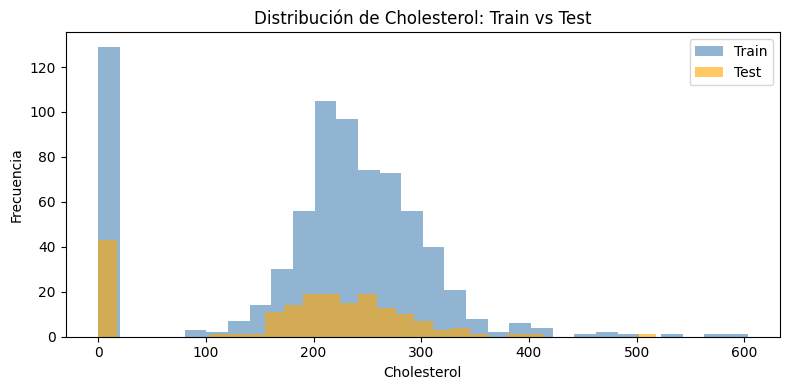

In [ ]:
#SEED
SEED = 42

# Generar dummies
df = pd.get_dummies(df, drop_first=True)

# Features y target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Partición 80 y 20 para entrenamiento y test respectivamente
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# Estadísticas descriptivas

print(f"Semilla utilizada: {SEED}\n")

print("=== Proporción de clases ===")
print(f"Train:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"\nTest:\n{y_test.value_counts(normalize=True).round(4)}")

print("\n=== Cholesterol ===")
for name, data in [("Train", X_train), ("Test", X_test)]:
    print(f"{name} - Media: {data['Cholesterol'].mean():.2f}, "
          f"Std: {data['Cholesterol'].std():.2f}")

print("\n=== Age ===")
for name, data in [("Train", X_train), ("Test", X_test)]:
    print(f"{name} - Media: {data['Age'].mean():.2f}, "
          f"Std: {data['Age'].std():.2f}")

# Histograma Cholesterol

plt.figure(figsize=(8, 4))
plt.hist(X_train['Cholesterol'], bins=30, alpha=0.6, label='Train', color='steelblue')
plt.hist(X_test['Cholesterol'],  bins=30, alpha=0.6, label='Test',  color='orange')
plt.xlabel('Cholesterol')
plt.ylabel('Frecuencia')
plt.title('Distribución de Cholesterol: Train vs Test')
plt.legend()
plt.tight_layout()
plt.savefig('cholesterol_dist.png', dpi=150)
plt.show()

##(c)


=== Métricas Train ===
Accuracy:    0.8624
Precision:   0.8657
Recall:      0.8892
Specificity: 0.8293
F1-Score:    0.8773
FPR:         0.1707
FNR:         0.1108

=== Métricas Test ===
Accuracy:    0.8859
Precision:   0.8716
Recall:      0.9314
Specificity: 0.8293
F1-Score:    0.9005
FPR:         0.1707
FNR:         0.0686


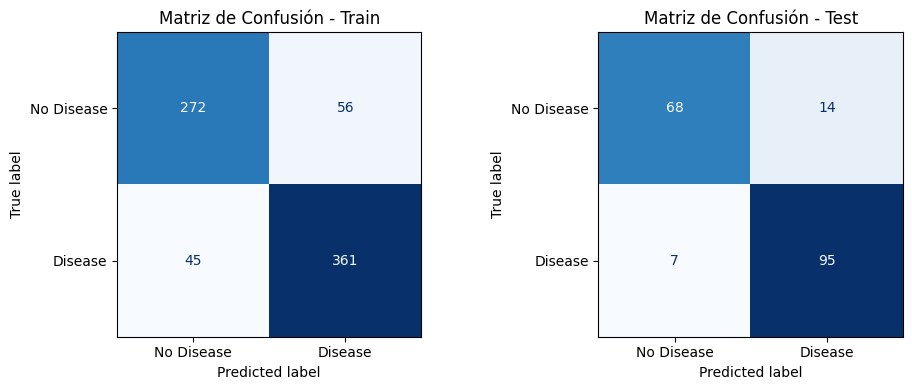

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Modelo baseline con hiperparámetros por defecto
lr = LogisticRegression(random_state=SEED, max_iter=1000)
lr.fit(X_train, y_train)

# Predicciones
y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

# Función para calcular métricas M

def metricas(y_true, y_pred, nombre=""):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy    = (TP + TN) / (TP + TN + FP + FN)
    precision   = TP / (TP + FP)
    recall      = TP / (TP + FN)       # TPR
    specificity = TN / (TN + FP)
    f1          = 2 * precision * recall / (precision + recall)
    fpr         = FP / (FP + TN)
    fnr         = FN / (FN + TP)

    print(f"\n=== Métricas {nombre} ===")
    print(f"Accuracy:    {accuracy:.4f}")
    print(f"Precision:   {precision:.4f}")
    print(f"Recall:      {recall:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"F1-Score:    {f1:.4f}")
    print(f"FPR:         {fpr:.4f}")
    print(f"FNR:         {fnr:.4f}")

    return {"Accuracy": accuracy, "Precision": precision,
            "Recall": recall, "Specificity": specificity,
            "F1": f1, "FPR": fpr, "FNR": fnr}

metrics_train = metricas(y_train, y_pred_train, "Train")
metrics_test  = metricas(y_test,  y_pred_test,  "Test")

# Matrices de confusión

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ["Train", "Test"]
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Matriz de Confusión - {title}")

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## (d)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Métricas Train 60% ===
Accuracy:    0.8618
Precision:   0.8654
Recall:      0.8882
Specificity: 0.8293
F1-Score:    0.8766
FPR:         0.1707
FNR:         0.1118

=== Métricas Test 40% ===
Accuracy:    0.8723
Precision:   0.8829
Recall:      0.8873
Specificity: 0.8537
F1-Score:    0.8851
FPR:         0.1463
FNR:         0.1127


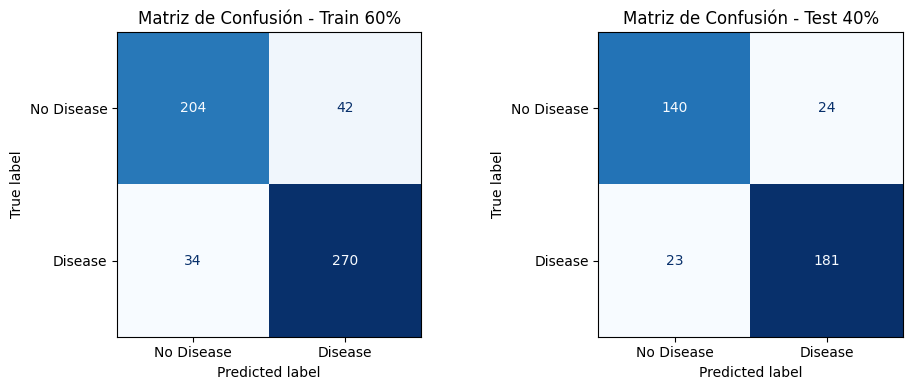

In [ ]:
# Partición 60/40 estratificada
X_train_60, X_test_40, y_train_60, y_test_40 = train_test_split(
    X, y, test_size=0.4, random_state=SEED, stratify=y
)

# Modelo con 60/40
lr_60 = LogisticRegression(random_state=SEED, max_iter=1000)
lr_60.fit(X_train_60, y_train_60)

# Predicciones
y_pred_train_60 = lr_60.predict(X_train_60)
y_pred_test_40  = lr_60.predict(X_test_40)

# Métricas
metrics_train_60 = metricas(y_train_60, y_pred_train_60, "Train 60%")
metrics_test_40  = metricas(y_test_40,  y_pred_test_40,  "Test 40%")

# Matrices de confusión

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_train_60, y_test_40],
    [y_pred_train_60, y_pred_test_40],
    ["Train 60%", "Test 40%"]
):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Matriz de Confusión - {title}")

plt.tight_layout()
plt.savefig('confusion_matrix_60_40.png', dpi=150)
plt.show()

## (e)


AUC Train 80%: 0.9327 | AUC Test 20%:  0.9311
AUC Train 60%: 0.9325 | AUC Test 40%: 0.9278


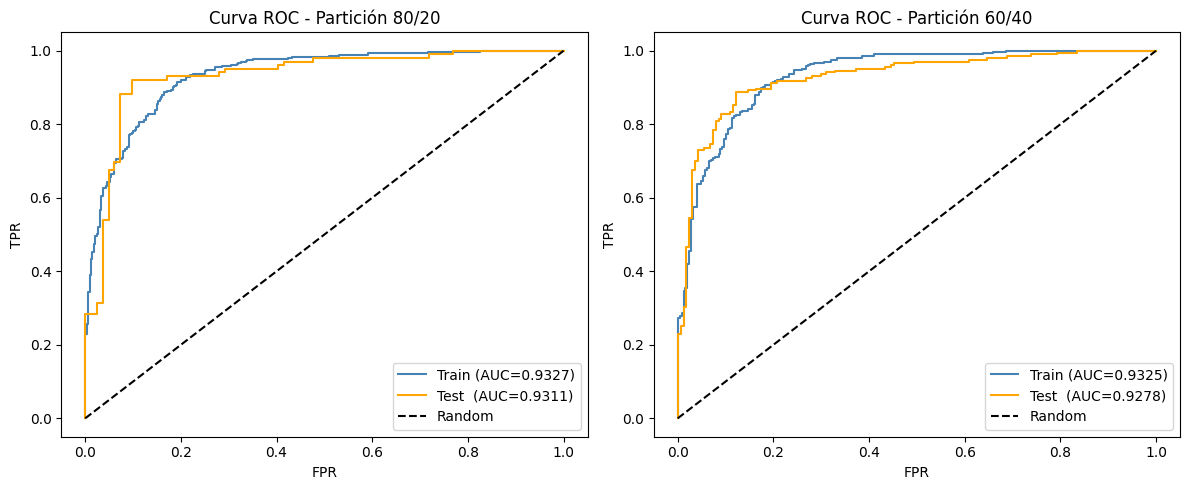

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidades para ambas particiones
y_prob_train_80 = lr.predict_proba(X_train)[:, 1]
y_prob_test_80  = lr.predict_proba(X_test)[:, 1]

y_prob_train_60 = lr_60.predict_proba(X_train_60)[:, 1]
y_prob_test_40  = lr_60.predict_proba(X_test_40)[:, 1]

# AUC
auc_train_80 = roc_auc_score(y_train, y_prob_train_80)
auc_test_80  = roc_auc_score(y_test,  y_prob_test_80)
auc_train_60 = roc_auc_score(y_train_60, y_prob_train_60)
auc_test_40  = roc_auc_score(y_test_40,  y_prob_test_40)

print(f"AUC Train 80%: {auc_train_80:.4f} | AUC Test 20%:  {auc_test_80:.4f}")
print(f"AUC Train 60%: {auc_train_60:.4f} | AUC Test 40%: {auc_test_40:.4f}")

# Curvas ROC

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_tr, y_te, prob_tr, prob_te, auc_tr, auc_te, title in zip(
    axes,
    [y_train,    y_train_60],
    [y_test,     y_test_40],
    [y_prob_train_80, y_prob_train_60],
    [y_prob_test_80,  y_prob_test_40],
    [auc_train_80, auc_train_60],
    [auc_test_80,  auc_test_40],
    ["80/20", "60/40"]
):
    fpr_tr, tpr_tr, _ = roc_curve(y_tr, prob_tr)
    fpr_te, tpr_te, _ = roc_curve(y_te, prob_te)

    ax.plot(fpr_tr, tpr_tr, label=f"Train (AUC={auc_tr:.4f})", color='steelblue')
    ax.plot(fpr_te, tpr_te, label=f"Test  (AUC={auc_te:.4f})", color='orange')
    ax.plot([0, 1], [0, 1], 'k--', label="Random")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(f"Curva ROC - Partición {title}")
    ax.legend()

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

## (g)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.1, 1, 10],
        'class_weight': ['balanced', None, {0:1, 1:5}],
        'solver': ['saga'],
        'max_iter': [10000],
        'random_state': [SEED]
    },
    {
        'penalty': ['elasticnet'],
        'C': [0.1, 1, 10],
        'class_weight': ['balanced', None, {0:1, 1:5}],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [10000],
        'random_state': [SEED]
    }
]

# Correr UNA sola vez con múltiples métricas
grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring={'AUC': 'roc_auc', 'Accuracy': 'accuracy', 'F1': 'f1'},
    refit='AUC',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Tabla de resultados
results = pd.DataFrame({
    'penalty':      [p['penalty'] for p in grid_search.cv_results_['params']],
    'C':            [p['C'] for p in grid_search.cv_results_['params']],
    'class_weight': [str(p['class_weight']) for p in grid_search.cv_results_['params']],
    'AUC':          grid_search.cv_results_['mean_test_AUC'].round(4),
    'Accuracy':     grid_search.cv_results_['mean_test_Accuracy'].round(4),
    'F1-Score':     grid_search.cv_results_['mean_test_F1'].round(4)
})

print(results.to_string(index=False))
results.to_csv('grid_results.csv', index=False)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
   penalty    C class_weight    AUC  Accuracy  F1-Score
        l1  0.1     balanced 0.8967    0.8405    0.8540
        l2  0.1     balanced 0.9045    0.8392    0.8530
        l1  0.1         None 0.8970    0.8365    0.8542
        l2  0.1         None 0.9039    0.8433    0.8596
        l1  0.1 {0: 1, 1: 5} 0.9063    0.7670    0.8208
        l2  0.1 {0: 1, 1: 5} 0.9110    0.7792    0.8290
        l1  1.0     balanced 0.9066    0.8419    0.8559
        l2  1.0     balanced 0.9074    0.8433    0.8573
        l1  1.0         None 0.9064    0.8474    0.8635
        l2  1.0         None 0.9073    0.8460    0.8624
        l1  1.0 {0: 1, 1: 5} 0.9131    0.7970    0.8408
        l2  1.0 {0: 1, 1: 5} 0.9135    0.7970    0.8408
        l1 10.0     balanced 0.9078    0.8433    0.8573
        l2 10.0     balanced 0.9078    0.8433    0.8573
        l1 10.0         None 0.9076    0.8474    0.8637
        l2 10.0         None 0.9077    0.8

## (h)

Normas por modelo:
Modelo  1 | penalty=l1         | ||beta||_2 = 1.2603
Modelo  2 | penalty=l2         | ||beta||_2 = 1.4018
Modelo  3 | penalty=l1         | ||beta||_2 = 1.2670
Modelo  4 | penalty=l2         | ||beta||_2 = 1.4083
Modelo  5 | penalty=l1         | ||beta||_2 = 1.8108
Modelo  6 | penalty=l2         | ||beta||_2 = 1.9838
Modelo  7 | penalty=l1         | ||beta||_2 = 1.5424
Modelo  8 | penalty=l2         | ||beta||_2 = 1.5586
Modelo  9 | penalty=l1         | ||beta||_2 = 1.5505
Modelo 10 | penalty=l2         | ||beta||_2 = 1.5666
Modelo 11 | penalty=l1         | ||beta||_2 = 2.2430
Modelo 12 | penalty=l2         | ||beta||_2 = 2.2592
Modelo 13 | penalty=l1         | ||beta||_2 = 1.5754
Modelo 14 | penalty=l2         | ||beta||_2 = 1.5771
Modelo 15 | penalty=l1         | ||beta||_2 = 1.5836
Modelo 16 | penalty=l2         | ||beta||_2 = 1.5853
Modelo 17 | penalty=l1         | ||beta||_2 = 2.2932
Modelo 18 | penalty=l2         | ||beta||_2 = 2.2947
Modelo 19 | penalty=elastic

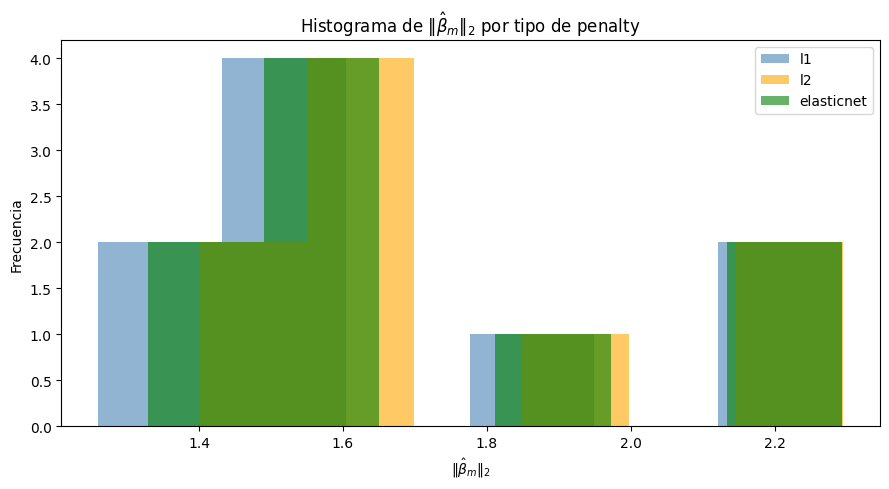

In [ ]:
## Ajustar los 27 modelos SIN validación cruzada

modelos = []
coef_normas = []
etiquetas_penalty = []

for params in grid_search.cv_results_['params']:
    model = LogisticRegression(**params)
    model.fit(X_train, y_train)

    beta = model.coef_[0]          # vector de coeficientes
    norma = np.linalg.norm(beta)   # ||beta||_2

    modelos.append(model)
    coef_normas.append(norma)
    etiquetas_penalty.append(params['penalty'])

# Convertir a arrays
coef_normas = np.array(coef_normas)
etiquetas_penalty = np.array(etiquetas_penalty)

print("Normas por modelo:")
for i, (norma, pen) in enumerate(zip(coef_normas, etiquetas_penalty)):
    print(f"Modelo {i+1:2d} | penalty={pen:10s} | ||beta||_2 = {norma:.4f}")

# Histograma coloreado por penalty

colors = {'l1': 'steelblue', 'l2': 'orange', 'elasticnet': 'green'}
penalty_tipos = ['l1', 'l2', 'elasticnet']

plt.figure(figsize=(9, 5))
for pen in penalty_tipos:
    mask = etiquetas_penalty == pen
    plt.hist(coef_normas[mask], bins=6, alpha=0.6,
             label=pen, color=colors[pen])

plt.xlabel(r'$\|\hat{\beta}_m\|_2$')
plt.ylabel('Frecuencia')
plt.title(r'Histograma de $\|\hat{\beta}_m\|_2$ por tipo de penalty')
plt.legend()
plt.tight_layout()
plt.savefig('histograma_normas.png', dpi=150)
plt.show()

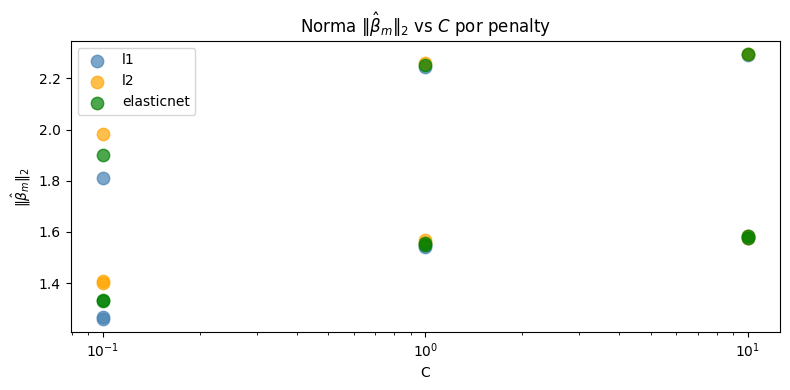

In [ ]:
#Grafico adicional comportamiento de C
fig, ax = plt.subplots(figsize=(8, 4))

for pen in penalty_tipos:
    mask = etiquetas_penalty == pen
    normas_pen = coef_normas[mask]
    cs_pen = [p['C'] for p in grid_search.cv_results_['params']
              if p['penalty'] == pen]
    ax.scatter(cs_pen, normas_pen, label=pen,
               color=colors[pen], alpha=0.7, s=80)

ax.set_xscale('log')
ax.set_xlabel('C')
ax.set_ylabel(r'$\|\hat{\beta}_m\|_2$')
ax.set_title(r'Norma $\|\hat{\beta}_m\|_2$ vs $C$ por penalty')
ax.legend()
plt.tight_layout()
plt.savefig('normas_vs_C.png', dpi=150)
plt.show()

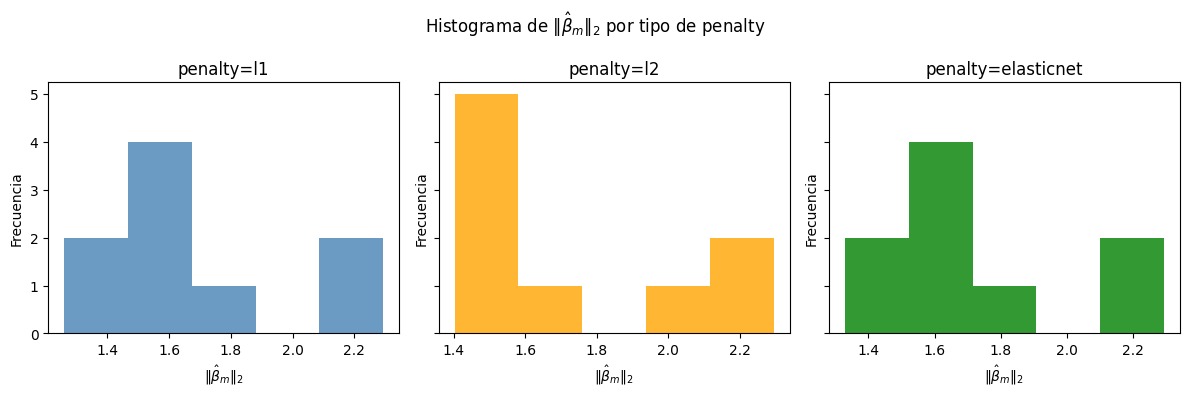

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, pen in zip(axes, penalty_tipos):
    mask = etiquetas_penalty == pen
    ax.hist(coef_normas[mask], bins=5, color=colors[pen], alpha=0.8)
    ax.set_title(f'penalty={pen}')
    ax.set_xlabel(r'$\|\hat{\beta}_m\|_2$')
    ax.set_ylabel('Frecuencia')

fig.suptitle(r'Histograma de $\|\hat{\beta}_m\|_2$ por tipo de penalty')
plt.tight_layout()
plt.savefig('histograma_normas.png', dpi=150)
plt.show()

## (i)

In [ ]:
# Vector unitario para cada modelo

beta_unit = []
nombres_variables = X_train.columns.tolist()

for model in modelos:
    beta = model.coef_[0]
    beta_norm = beta / np.linalg.norm(beta)  # vector unitario
    beta_unit.append(beta_norm)

beta_unit = np.array(beta_unit)  # shape (27, p)

print(f"Número de variables p = {beta_unit.shape[1]}")
print(f"Número de modelos = {beta_unit.shape[0]}")

# (i) Variable dominante por modelo

print("\n=== Variable dominante por modelo ===")
print(f"{'Modelo':>7} | {'penalty':>10} | {'C':>4} | {'class_weight':>12} | {'Variable dominante':>25} | {'|beta_j|':>8}")

for i, (beta_u, params) in enumerate(zip(beta_unit, grid_search.cv_results_['params'])):
    j_star = np.argmax(np.abs(beta_u))
    var_dominante = nombres_variables[j_star]
    valor = np.abs(beta_u[j_star])
    print(f"{i+1:>7} | {params['penalty']:>10} | {params['C']:>4} | "
          f"{str(params['class_weight']):>12} | {var_dominante:>25} | {valor:.4f}")

Número de variables p = 15
Número de modelos = 27

=== Variable dominante por modelo ===
 Modelo |    penalty |    C | class_weight |        Variable dominante | |beta_j|
      1 |         l1 |  0.1 |     balanced |               ST_Slope_Up | 0.5476
      2 |         l2 |  0.1 |     balanced |               ST_Slope_Up | 0.5018
      3 |         l1 |  0.1 |         None |               ST_Slope_Up | 0.5494
      4 |         l2 |  0.1 |         None |               ST_Slope_Up | 0.5034
      5 |         l1 |  0.1 | {0: 1, 1: 5} |               ST_Slope_Up | 0.5264
      6 |         l2 |  0.1 | {0: 1, 1: 5} |               ST_Slope_Up | 0.4932
      7 |         l1 |    1 |     balanced |               ST_Slope_Up | 0.5059
      8 |         l2 |    1 |     balanced |               ST_Slope_Up | 0.5013
      9 |         l1 |    1 |         None |               ST_Slope_Up | 0.5074
     10 |         l2 |    1 |         None |               ST_Slope_Up | 0.5028
     11 |         l1 |    1 |

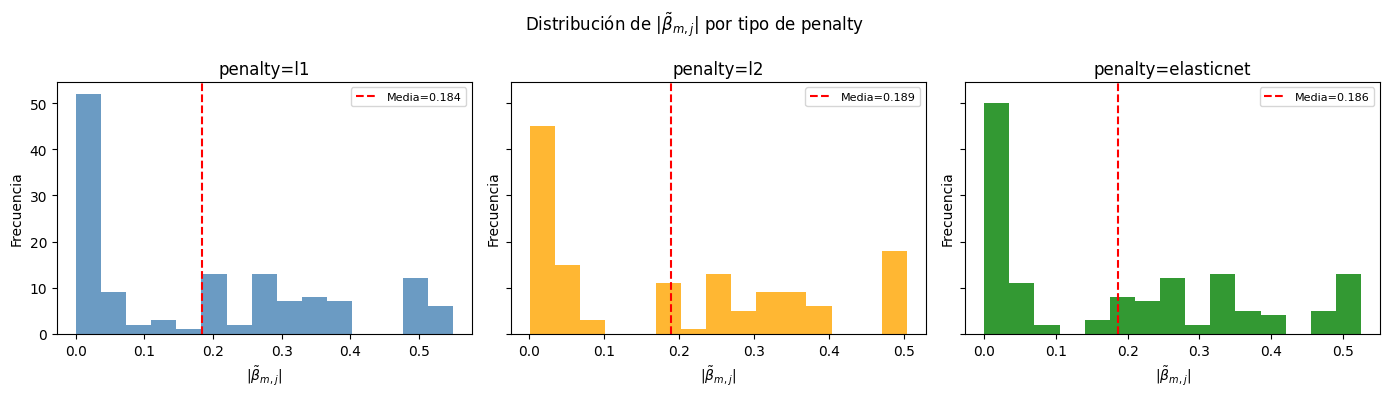

=== Estadísticas de |beta_unitario| por penalty ===

l1:
  Media:   0.1839
  Std:     0.1812
  % zeros: 5.9%

l2:
  Media:   0.1895
  Std:     0.1754
  % zeros: 0.0%

elasticnet:
  Media:   0.1860
  Std:     0.1791
  % zeros: 5.2%


In [ ]:
#(iii)
# Histograma agregado de |beta_unitario| por penalty

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, pen in zip(axes, penalty_tipos):
    mask = etiquetas_penalty == pen
    # Obtener todos los |beta_unitario| de los modelos con ese penalty
    valores = np.abs(beta_unit[mask]).flatten()

    ax.hist(valores, bins=15, color=colors[pen], alpha=0.8)
    ax.set_title(f'penalty={pen}')
    ax.set_xlabel(r'$|\tilde{\beta}_{m,j}|$')
    ax.set_ylabel('Frecuencia')
    ax.axvline(np.mean(valores), color='red',
               linestyle='--', label=f'Media={np.mean(valores):.3f}')
    ax.legend(fontsize=8)

fig.suptitle(r'Distribución de $|\tilde{\beta}_{m,j}|$ por tipo de penalty')
plt.tight_layout()
plt.savefig('hist_beta_unitario.png', dpi=150)
plt.show()

# Estadísticas por penalty
print("=== Estadísticas de |beta_unitario| por penalty ===")
for pen in penalty_tipos:
    mask = etiquetas_penalty == pen
    valores = np.abs(beta_unit[mask]).flatten()
    print(f"\n{pen}:")
    print(f"  Media:   {np.mean(valores):.4f}")
    print(f"  Std:     {np.std(valores):.4f}")
    print(f"  % zeros: {(valores < 1e-6).mean()*100:.1f}%")

In [ ]:
#(iv)
#  Distancia coseno respecto a la mediana de los beta_unitarios

# Mediana componente a componente
beta_mediana = np.median(beta_unit, axis=0)
beta_mediana_norm = beta_mediana / np.linalg.norm(beta_mediana)

# Distancia coseno = 1 - similitud coseno
from numpy.linalg import norm

print("=== Distancia coseno respecto a la mediana ===")
print(f"{'Modelo':>7} | {'penalty':>10} | {'C':>4} | "
      f"{'class_weight':>12} | {'dist_coseno':>11} | {'n_zeros':>7}")

distancias = []
n_zeros = []

for i, (beta_u, params) in enumerate(zip(beta_unit,
                                          grid_search.cv_results_['params'])):
    # Similitud coseno
    sim = np.dot(beta_u, beta_mediana_norm) / (norm(beta_u) * norm(beta_mediana_norm))
    dist = 1 - sim
    nz = np.sum(np.abs(beta_u) < 1e-6)

    distancias.append(dist)
    n_zeros.append(nz)

    print(f"{i+1:>7} | {params['penalty']:>10} | {params['C']:>4} | "
          f"{str(params['class_weight']):>12} | {dist:>11.6f} | {nz:>7}")

distancias = np.array(distancias)
print(f"\nModelo más atípico: Modelo {np.argmax(distancias)+1} "
      f"con distancia coseno = {np.max(distancias):.6f}")

=== Distancia coseno respecto a la mediana ===
 Modelo |    penalty |    C | class_weight | dist_coseno | n_zeros
      1 |         l1 |  0.1 |     balanced |    0.014719 |       3
      2 |         l2 |  0.1 |     balanced |    0.000566 |       0
      3 |         l1 |  0.1 |         None |    0.014595 |       3
      4 |         l2 |  0.1 |         None |    0.000453 |       0
      5 |         l1 |  0.1 | {0: 1, 1: 5} |    0.008807 |       2
      6 |         l2 |  0.1 | {0: 1, 1: 5} |    0.010339 |       0
      7 |         l1 |    1 |     balanced |    0.000133 |       0
      8 |         l2 |    1 |     balanced |    0.000125 |       0
      9 |         l1 |    1 |         None |    0.000124 |       0
     10 |         l2 |    1 |         None |    0.000057 |       0
     11 |         l1 |    1 | {0: 1, 1: 5} |    0.016875 |       0
     12 |         l2 |    1 | {0: 1, 1: 5} |    0.017692 |       0
     13 |         l1 |   10 |     balanced |    0.000108 |       0
     14 |      

## (j)

In [ ]:
#Mejor combinación según AUC y F1-Score

print("=== Mejor combinación según AUC ===")
idx_auc = results['AUC'].idxmax()
print(results.iloc[idx_auc])

print("\n=== Mejor combinación según F1-Score ===")
idx_f1 = results['F1-Score'].idxmax()
print(results.iloc[idx_f1])

print("\n=== Mejor combinación según Accuracy ===")
idx_acc = results['Accuracy'].idxmax()
print(results.iloc[idx_acc])

# Norma y beta unitario de las mejores combinaciones
print(f"\n||beta||_2 mejor AUC:      {coef_normas[idx_auc]:.4f}")
print(f"||beta||_2 mejor F1-Score: {coef_normas[idx_f1]:.4f}")

print(f"\nVariable dominante mejor AUC:      "
      f"{nombres_variables[np.argmax(np.abs(beta_unit[idx_auc]))]}")
print(f"Variable dominante mejor F1-Score: "
      f"{nombres_variables[np.argmax(np.abs(beta_unit[idx_f1]))]}")

=== Mejor combinación según AUC ===
penalty                   l1
C                       10.0
class_weight    {0: 1, 1: 5}
AUC                   0.9139
Accuracy               0.801
F1-Score              0.8442
Name: 16, dtype: object

=== Mejor combinación según F1-Score ===
penalty             l2
C                 10.0
class_weight      None
AUC             0.9077
Accuracy        0.8487
F1-Score        0.8652
Name: 15, dtype: object

=== Mejor combinación según Accuracy ===
penalty             l2
C                 10.0
class_weight      None
AUC             0.9077
Accuracy        0.8487
F1-Score        0.8652
Name: 15, dtype: object

||beta||_2 mejor AUC:      2.2932
||beta||_2 mejor F1-Score: 1.5853

Variable dominante mejor AUC:      ST_Slope_Up
Variable dominante mejor F1-Score: ST_Slope_Up


## (j)

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Mejor modelo de Regresión Logística de (j) según AUC
best_lr = LogisticRegression(penalty='l1', C=10, class_weight={0:1, 1:5},
                              solver='saga', max_iter=10000, random_state=SEED)

# Clasificadores
clasificadores = {
    'Log. Reg. (best)': best_lr,
    'Perceptron':       Perceptron(random_state=SEED),
    'KNN':              KNeighborsClassifier(),
    'Gaussian NB':      GaussianNB(),
    'LDA':              LinearDiscriminantAnalysis()
}

# Métricas para todos los clasificadores

resultados_k = {}

for nombre, clf in clasificadores.items():
    clf.fit(X_train, y_train)

    y_pred_tr = clf.predict(X_train)
    y_pred_te = clf.predict(X_test)

    print(f"\n{'='*10} {nombre} {'='*10}")
    m_tr = metricas(y_train, y_pred_tr, f"{nombre} - Train")
    m_te = metricas(y_test,  y_pred_te, f"{nombre} - Test")

    resultados_k[nombre] = {'train': m_tr, 'test': m_te}


========== Log. Reg. (best) ==========

=== Métricas Log. Reg. (best) - Train ===
Accuracy:    0.8120
Precision:   0.7548
Recall:      0.9778
Specificity: 0.6067
F1-Score:    0.8519
FPR:         0.3933
FNR:         0.0222

=== Métricas Log. Reg. (best) - Test ===
Accuracy:    0.8098
Precision:   0.7519
Recall:      0.9804
Specificity: 0.5976
F1-Score:    0.8511
FPR:         0.4024
FNR:         0.0196

========== Perceptron ==========

=== Métricas Perceptron - Train ===
Accuracy:    0.5545
Precision:   0.5539
Recall:      1.0000
Specificity: 0.0030
F1-Score:    0.7129
FPR:         0.9970
FNR:         0.0000

=== Métricas Perceptron - Test ===
Accuracy:    0.5489
Precision:   0.5519
Recall:      0.9902
Specificity: 0.0000
F1-Score:    0.7088
FPR:         1.0000
FNR:         0.0098

========== KNN ==========

=== Métricas KNN - Train ===
Accuracy:    0.7807
Precision:   0.7938
Recall:      0.8153
Specificity: 0.7378
F1-Score:    0.8044
FPR:         0.2622
FNR:         0.1847

=== Métric

## (l)

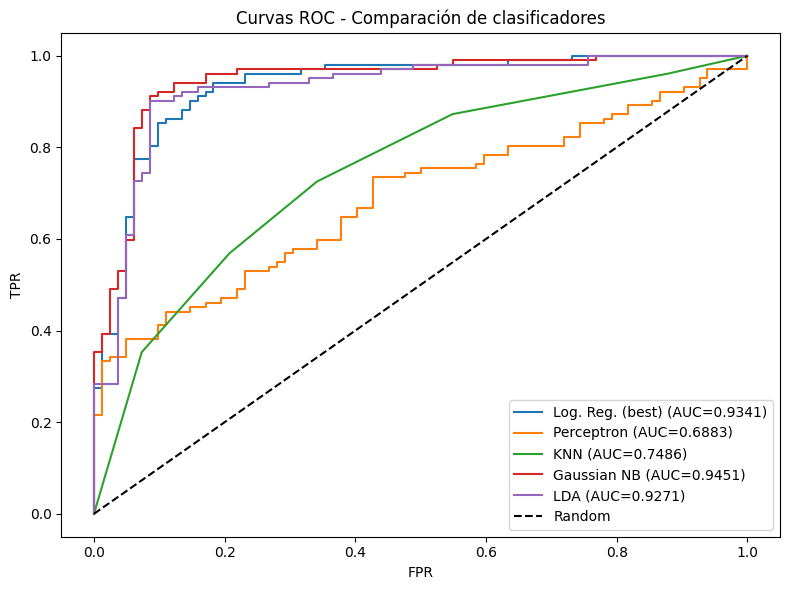

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

for nombre, clf in clasificadores.items():
    # Usar decision_function para Perceptron
    if hasattr(clf, 'predict_proba'):
        y_score = clf.predict_proba(X_test)[:, 1]
    else:
        y_score = clf.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Curvas ROC - Comparación de clasificadores')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_todos.png', dpi=150)
plt.show()

## (m)

In [ ]:
# Definir subconjuntos de variables

# Variables originales antes de dummies
vars_categoricas_orig = ['Sex', 'ChestPainType', 'RestingECG',
                          'ExerciseAngina', 'ST_Slope']
vars_numericas_orig   = ['Age', 'RestingBP', 'Cholesterol',
                          'FastingBS', 'MaxHR', 'Oldpeak']

# Obtener columnas dummies correspondientes
cols_categoricas = [c for c in X_train.columns
                    if any(c.startswith(v) for v in vars_categoricas_orig)]
cols_numericas   = [c for c in X_train.columns
                    if any(c.startswith(v) for v in vars_numericas_orig)]

print("Variables categóricas:", cols_categoricas)
print("Variables numéricas:",   cols_numericas)

# Entrenar y evaluar todos los modelos en cada subconjunto

subconjuntos = {
    'Categóricas': cols_categoricas,
    'Numéricas':   cols_numericas,
    'Todas':       list(X_train.columns)
}

from sklearn.model_selection import cross_val_score

resultados_m = []

for subset_name, cols in subconjuntos.items():
    X_tr = X_train[cols]
    X_te = X_test[cols]

    for nombre, clf in clasificadores.items():
        clf_fresh = clf.__class__(**clf.get_params())
        clf_fresh.fit(X_tr, y_train)

        # AUC
        if hasattr(clf_fresh, 'predict_proba'):
            y_score = clf_fresh.predict_proba(X_te)[:, 1]
        else:
            y_score = clf_fresh.decision_function(X_te)

        auc = roc_auc_score(y_test, y_score)

        # Accuracy y F1
        y_pred = clf_fresh.predict(X_te)
        acc = (y_pred == y_test).mean()

        from sklearn.metrics import f1_score
        f1 = f1_score(y_test, y_pred)

        resultados_m.append({
            'Subconjunto': subset_name,
            'Modelo':      nombre,
            'AUC':         round(auc, 4),
            'Accuracy':    round(acc, 4),
            'F1-Score':    round(f1, 4)
        })

df_m = pd.DataFrame(resultados_m)
print(df_m.to_string(index=False))
df_m.to_csv('resultados_m.csv', index=False)

Variables categóricas: ['Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']
Variables numéricas: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Subconjunto           Modelo    AUC  Accuracy  F1-Score
Categóricas Log. Reg. (best) 0.9088    0.7989    0.8398
Categóricas       Perceptron 0.8754    0.7772    0.7684
Categóricas              KNN 0.8974    0.8641    0.8768
Categóricas      Gaussian NB 0.9113    0.8533    0.8629
Categóricas              LDA 0.9020    0.8370    0.8558
  Numéricas Log. Reg. (best) 0.8741    0.6196    0.7426
  Numéricas       Perceptron 0.7620    0.6739    0.6552
  Numéricas              KNN 0.7478    0.6957    0.7255
  Numéricas      Gaussian NB 0.8876    0.8261    0.8416
  Numéricas              LDA 0.8674    0.7554    0.7847
      Todas Log. Reg. (best) 0.9341    0.8098    0.8511
      Todas       Perceptron 0.6883    0.5489    0.70